In [44]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import layers, models
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import time

In [2]:
plt.rcParams.update({
    'font.family': 'Liberation Serif',
    'font.size': 15,
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'axes.labelsize': 15,
    'axes.titlesize': 15,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 13
})

In [37]:
(x_train, y_train),(x_test, y_test) = cifar10.load_data()

In [38]:
y_train = y_train.flatten()
y_test = y_test.flatten()
print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing data shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)

Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000,)
Testing data shape: (10000, 32, 32, 3)
Testing labels shape: (10000,)


In [39]:
class_names = ["Airplane","Automobile","Bird","Cat","Deer","Dog","Frog","Horse","Ship","Truck"]
print("Class Labels")
for i, name in enumerate(class_names):
    print(f"{i} --> {name}")

Class Labels
0 --> Airplane
1 --> Automobile
2 --> Bird
3 --> Cat
4 --> Deer
5 --> Dog
6 --> Frog
7 --> Horse
8 --> Ship
9 --> Truck


In [40]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


Task 1

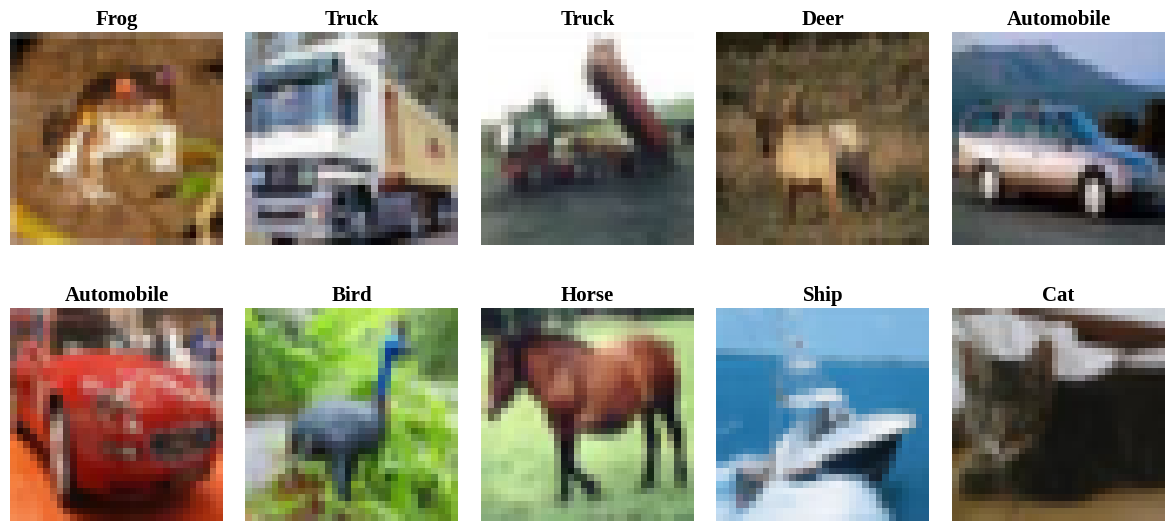

In [41]:
plt.figure(figsize=(12,6))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.tight_layout()
plt.savefig("Sample_images.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

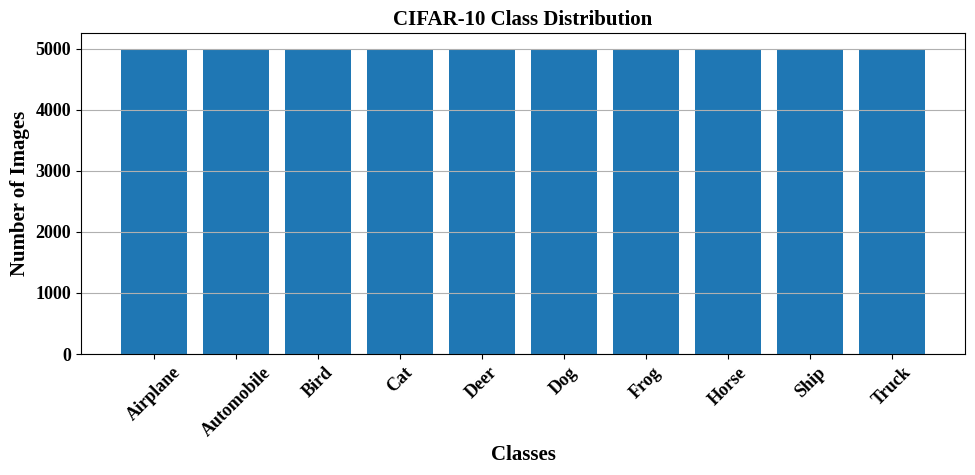

In [42]:
class_counts = np.bincount(y_train.flatten())
plt.figure(figsize=(10, 5))
plt.bar(class_names, class_counts)
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("CIFAR-10 Class Distribution")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.tight_layout()
plt.savefig("Class_distribution.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

Task 2

3 × 3 Kernel → Feature Map Size: (30, 30)
5 × 5 Kernel → Feature Map Size: (28, 28)
7 × 7 Kernel → Feature Map Size: (26, 26)


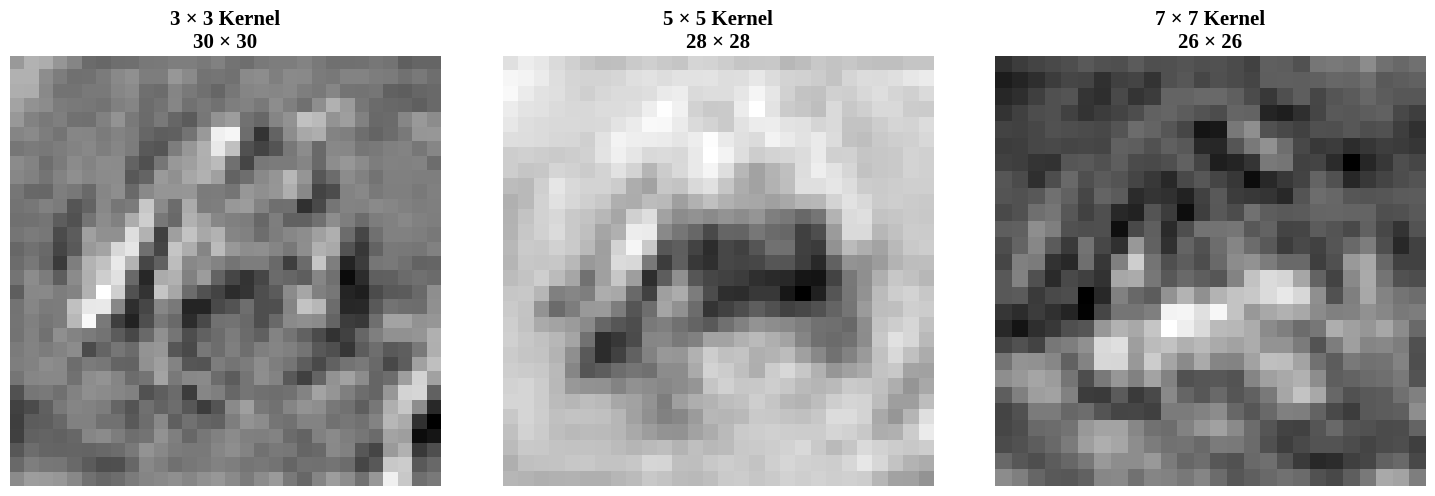

In [45]:
sample_image = x_train[0]
kernels = [3, 5, 7]
plt.figure(figsize=(15, 5))
for i, kernel_size in enumerate(kernels):
    conv = layers.Conv2D(filters=1,kernel_size=(kernel_size, kernel_size),strides=1,padding='valid')
    input_image = np.expand_dims(sample_image, axis=0)
    output = conv(input_image)
    feature_map = output[0, :, :, 0]
    print(
        f"{kernel_size} × {kernel_size} Kernel → "
        f"Feature Map Size: {feature_map.shape}"
    )
    plt.subplot(1, 3, i + 1)
    plt.imshow(feature_map, cmap='gray')
    plt.title(
        f"{kernel_size} × {kernel_size} Kernel\n"
        f"{feature_map.shape[0]} × {feature_map.shape[1]}"
    )
    plt.axis('off')
plt.tight_layout()
plt.savefig("Kernel_Comparison.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

Task 3

Valid Padding, Stride = 1 → Output Size: (30, 30)
Valid Padding, Stride = 2 → Output Size: (15, 15)
Same Padding, Stride = 1 → Output Size: (32, 32)
Same Padding, Stride = 2 → Output Size: (16, 16)


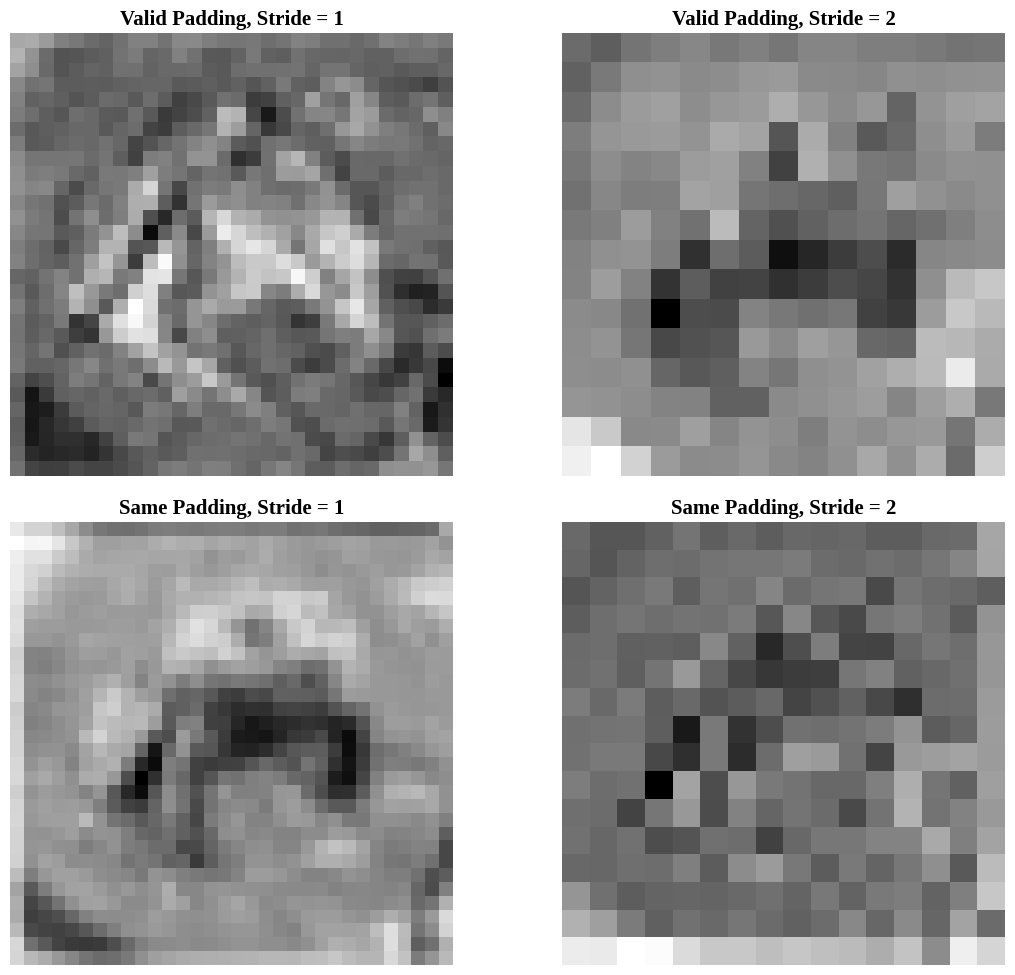

In [46]:
settings = [
    ("Valid Padding, Stride = 1", 1, "valid"),
    ("Valid Padding, Stride = 2", 2, "valid"),
    ("Same Padding, Stride = 1", 1, "same"),
    ("Same Padding, Stride = 2", 2, "same")
]
plt.figure(figsize=(12, 10))
for i, (title, stride, padding) in enumerate(settings):
    conv = layers.Conv2D(filters=1,kernel_size=(3, 3),strides=stride,padding=padding)
    input_image = np.expand_dims(sample_image, axis=0)
    output = conv(input_image)
    feature_map = output[0, :, :, 0]
    print(
        f"{title} → "
        f"Output Size: {feature_map.shape}"
    )
    plt.subplot(2, 2, i + 1)
    plt.imshow(feature_map, cmap='gray')
    plt.title(title)
    plt.axis('off')
plt.tight_layout()
plt.savefig("Stride_Padding_Comparison.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

Task 4

In [47]:
feature_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(16, (3, 3), padding='same'),
    layers.ReLU()
])
sample = np.expand_dims(x_train[0], axis=0)
feature_maps = feature_model.predict(sample, verbose=0)
print("Feature map shape:", feature_maps.shape)

Feature map shape: (1, 32, 32, 16)


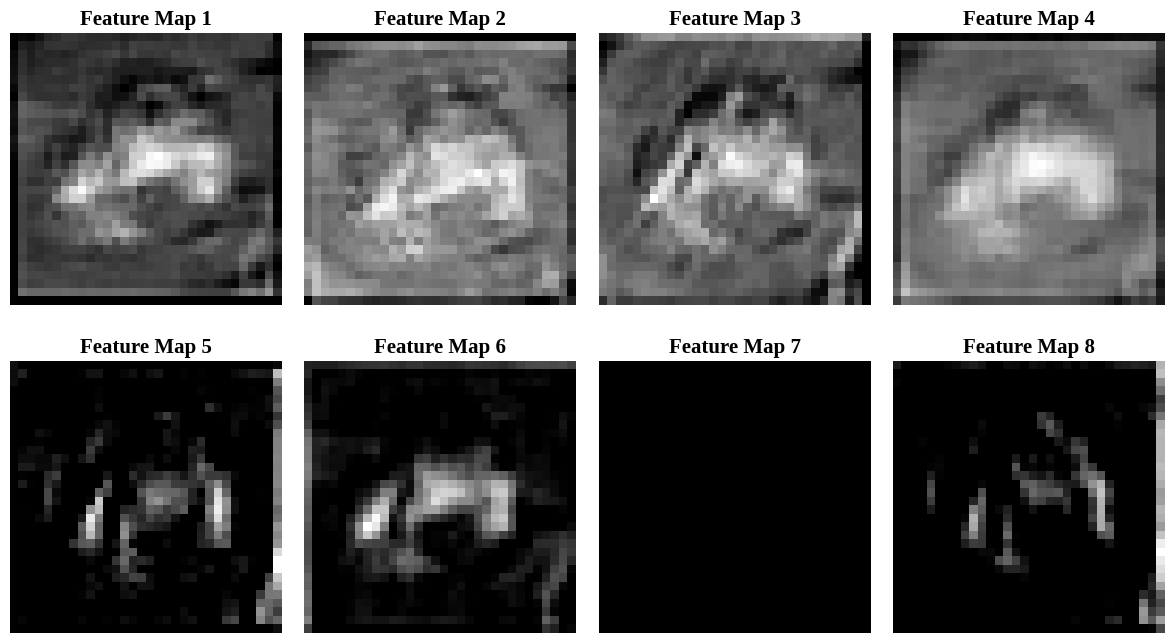

In [48]:
plt.figure(figsize=(12, 7))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(feature_maps[0, :, :, i], cmap='gray')
    plt.title(f"Feature Map {i + 1}")
    plt.axis('off')
plt.tight_layout()
plt.savefig("Feature_Maps.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

Task 5

In [49]:
sample = np.expand_dims(x_train[0], axis=0)
max_pool = layers.MaxPooling2D(pool_size=(2, 2),strides=2)
avg_pool = layers.AveragePooling2D(pool_size=(2, 2),strides=2)
max_output = max_pool(sample)
avg_output = avg_pool(sample)
print("Input shape:", sample.shape)
print("Max Pooling output:", max_output.shape)
print("Average Pooling output:", avg_output.shape)

Input shape: (1, 32, 32, 3)
Max Pooling output: (1, 16, 16, 3)
Average Pooling output: (1, 16, 16, 3)


Task 6

In [50]:
model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(16,(3, 3),padding='same'),
    layers.ReLU(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(32,(3, 3),padding='same'),
    layers.ReLU(),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(128),
    layers.ReLU(),
    layers.Dense(10,activation='softmax')
])

In [52]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_6 (ReLU)                  │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 268,650 (1.02 MB)

 Trainable params: 268,650 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [53]:
history = model.fit(x_train,y_train,validation_split=0.1,epochs=20,batch_size=32,verbose=1)

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 69s 48ms/step - accuracy: 0.4840 - loss: 1.4421 - val_accuracy: 0.5894 - val_loss: 1.1651
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 65s 36ms/step - accuracy: 0.6165 - loss: 1.0883 - val_accuracy: 0.6540 - val_loss: 1.0089
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 102s 51ms/step - accuracy: 0.6651 - loss: 0.9552 - val_accuracy: 0.6704 - val_loss: 0.9562
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 70s 50ms/step - accuracy: 0.6943 - loss: 0.8744 - val_accuracy: 0.6790 - val_loss: 0.9479
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 78s 47ms/step - accuracy: 0.7187 - loss: 0.8007 - val_accuracy: 0.6708 - val_loss: 0.9625
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 76s 54ms/step - accuracy: 0.7461 - loss: 0.7286 - val_accuracy: 0.6846 - val_loss: 0.9595
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 79s 56ms/step - accuracy: 0.7628 - loss: 0.6745 - val_accuracy: 0.6908 - val_loss: 0.9269
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 70s 50ms/step - accuracy: 0.7850 

In [54]:
final_train_accuracy = history.history['accuracy'][-1]
final_val_accuracy = history.history['val_accuracy'][-1]
print("Final Training Accuracy:",final_train_accuracy)
print("Final Validation Accuracy:",final_val_accuracy)

Final Training Accuracy: 0.9491999745368958
Final Validation Accuracy: 0.6736000180244446


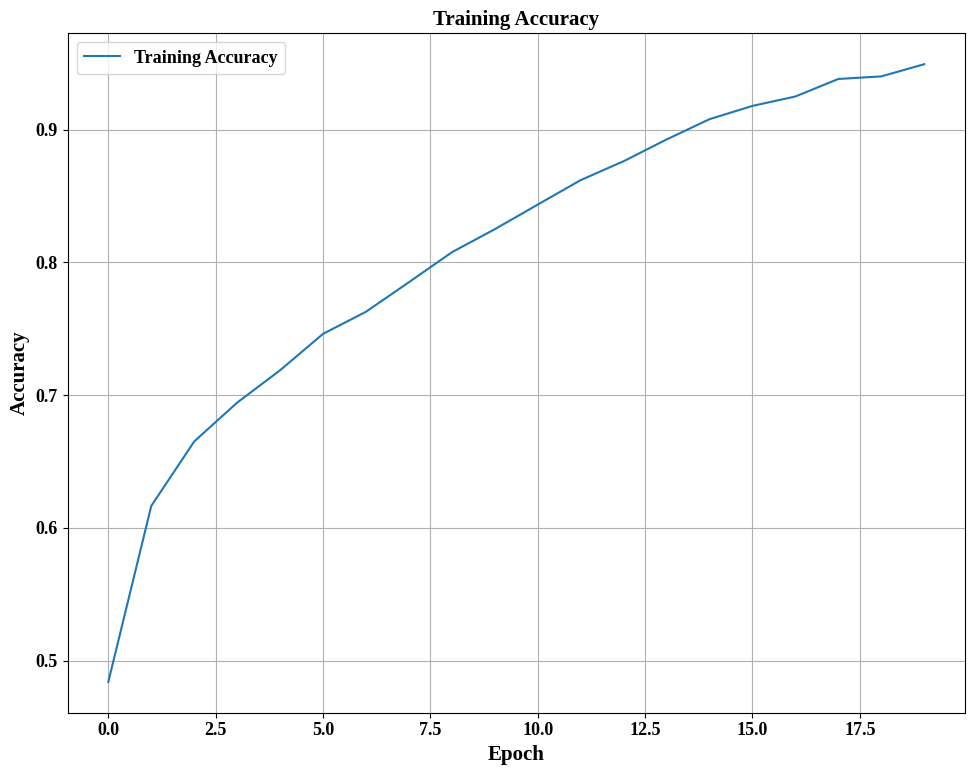

In [55]:
plt.figure(figsize=(10, 8))
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("Training_Accuracy.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

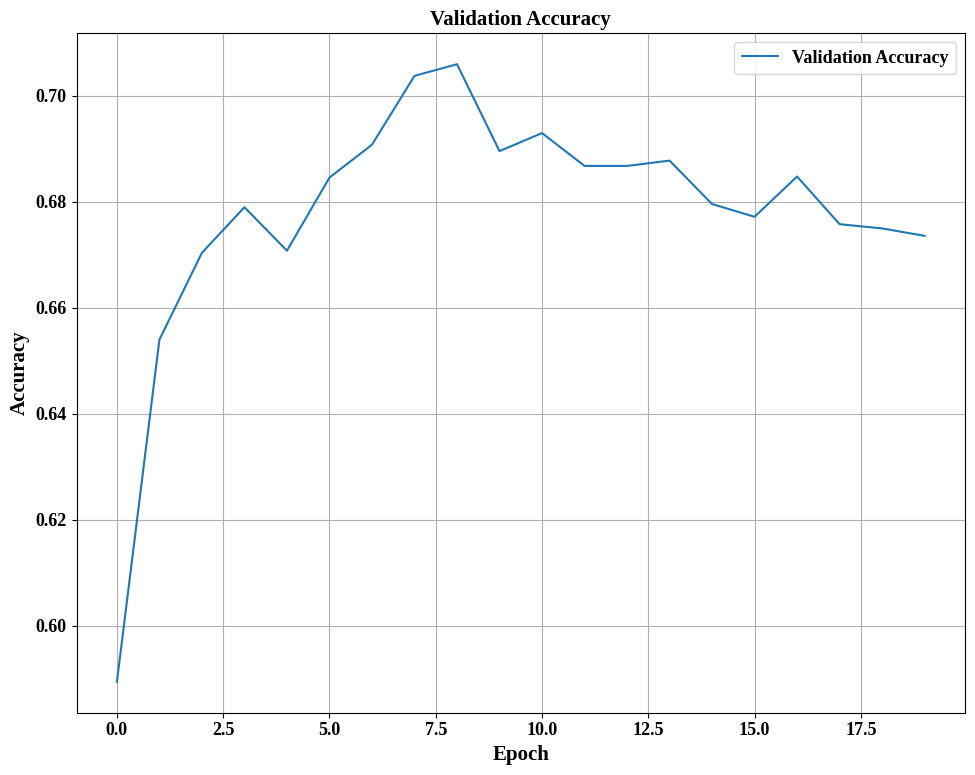

In [56]:
plt.figure(figsize=(10, 8))
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("Validation_Accuracy.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

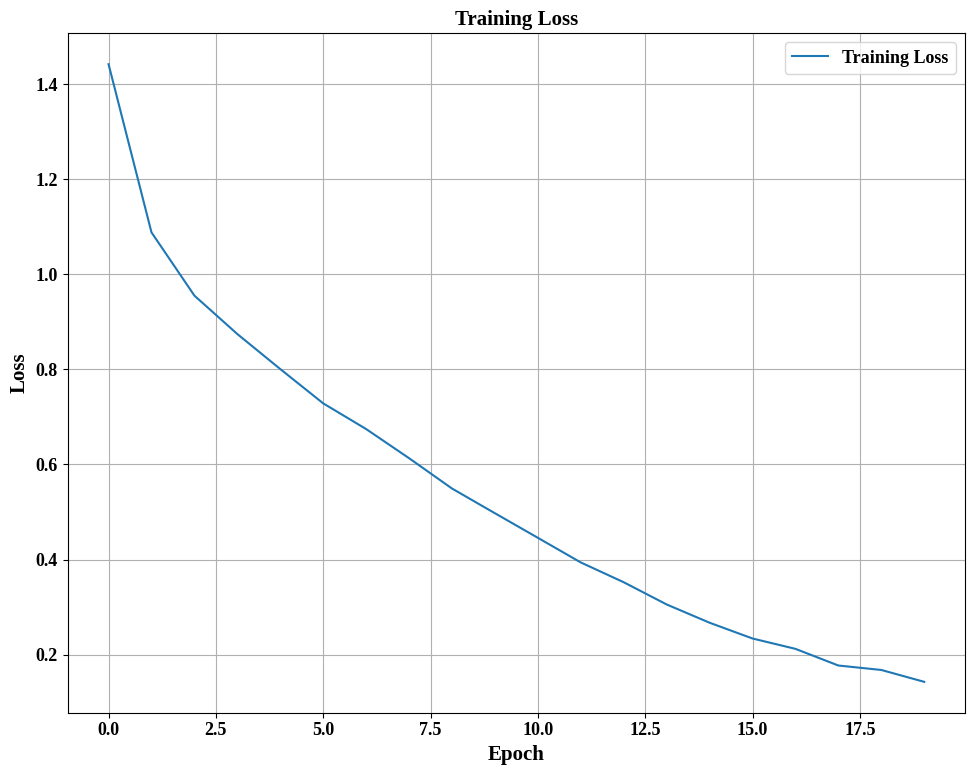

In [57]:
plt.figure(figsize=(10, 8))
plt.plot(history.history['loss'],label='Training Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("Training_Loss.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

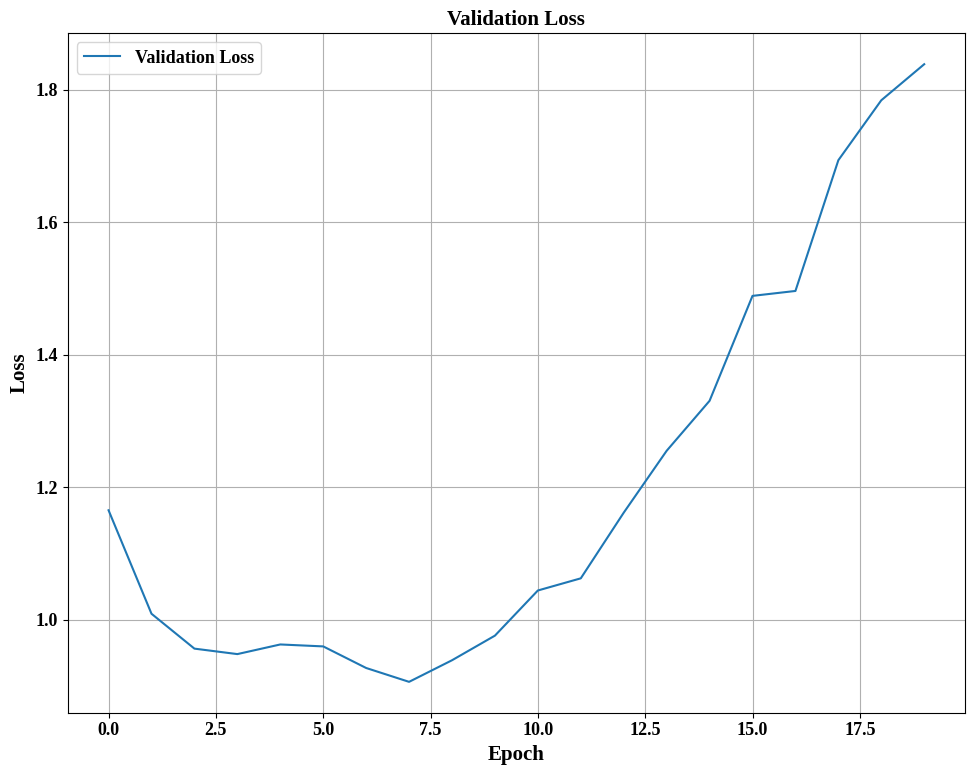

In [58]:
plt.figure(figsize=(10, 8))
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("Validation_Loss.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

In [59]:
test_loss, test_accuracy = model.evaluate(x_test,y_test,verbose=1)
print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6637 - loss: 1.8765
Test Accuracy: 0.6636999845504761
Test Loss: 1.876468539237976


In [60]:
y_prob = model.predict(x_test,verbose=1)
y_pred = np.argmax(y_prob,axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


In [61]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test,y_pred,average='weighted')
recall = recall_score(y_test,y_pred,average='weighted')
f1 = f1_score(y_test,y_pred,average='weighted')
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

Accuracy : 0.6637
Precision: 0.6670644973696475
Recall   : 0.6637
F1-score : 0.6638806063212672


In [62]:
print(classification_report(y_test,y_pred,target_names=class_names))

              precision    recall  f1-score   support

    Airplane       0.72      0.71      0.72      1000
  Automobile       0.74      0.78      0.76      1000
        Bird       0.57      0.55      0.56      1000
         Cat       0.46      0.46      0.46      1000
        Deer       0.55      0.68      0.61      1000
         Dog       0.57      0.52      0.54      1000
        Frog       0.70      0.76      0.73      1000
       Horse       0.75      0.70      0.73      1000
        Ship       0.80      0.78      0.79      1000
       Truck       0.80      0.69      0.74      1000

    accuracy                           0.66     10000
   macro avg       0.67      0.66      0.66     10000
weighted avg       0.67      0.66      0.66     10000



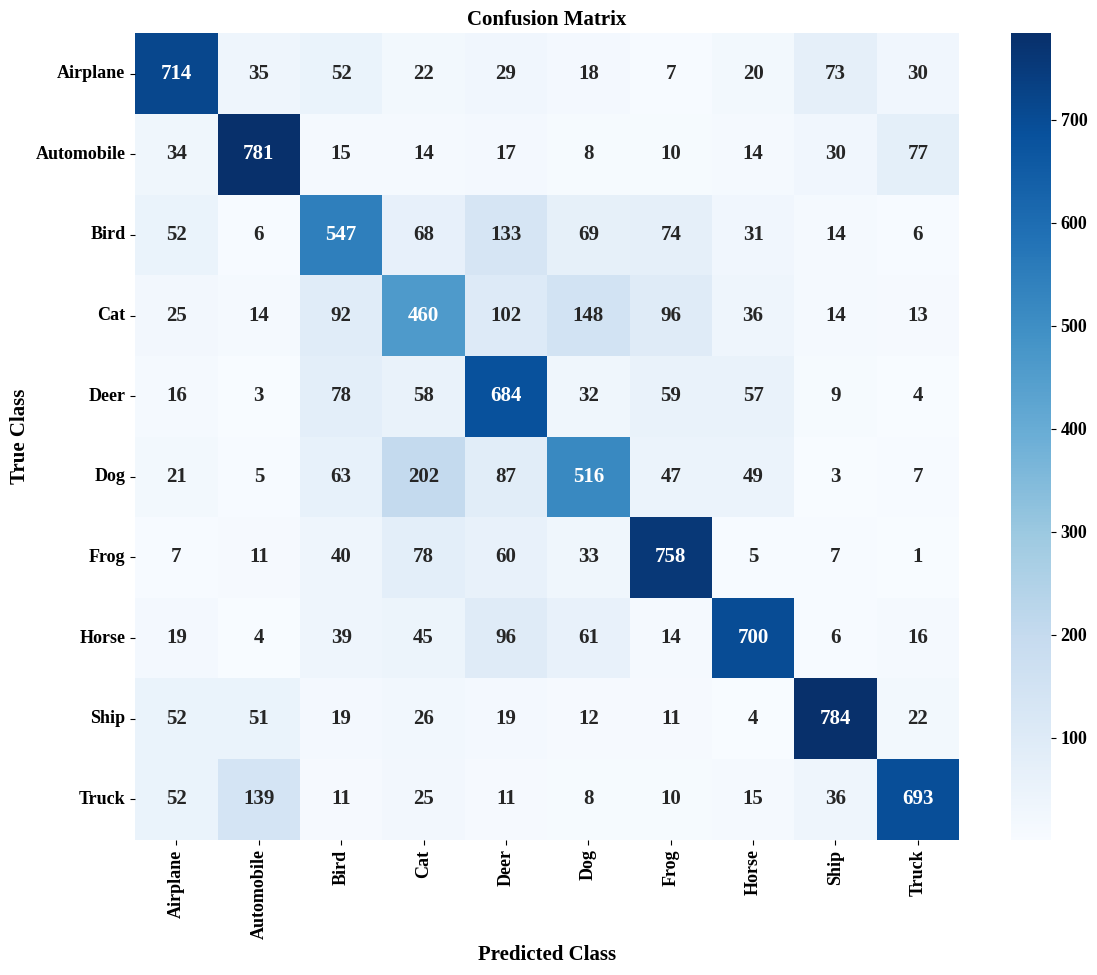

In [63]:
cm = confusion_matrix(y_test,y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=class_names,yticklabels=class_names)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("Confusion_Matrix.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

In [65]:
print("FINAL RESULTS:")
print(f"Training Accuracy : {final_train_accuracy:.4f}")
print(f"Testing Accuracy  : {test_accuracy:.4f}")
print(f"Precision         : {precision:.4f}")
print(f"Recall            : {recall:.4f}")
print(f"F1-score          : {f1:.4f}")
print(f"Parameters        : {model.count_params()}")

FINAL RESULTS:
Training Accuracy : 0.9492
Testing Accuracy  : 0.6637
Precision         : 0.6671
Recall            : 0.6637
F1-score          : 0.6639
Parameters        : 268650


Additional Exercise

Exercise 1

In [71]:
N = 64
F = 5
P = 2
S = 2
output = ((N - F + 2 * P) // S) + 1
print("Output size:", output, "×", output)

Output size: 32 × 32


Exercise 2

In [72]:
parameters = (3 * 3 * 3 + 1) * 64
print("Trainable parameters:", parameters)

Trainable parameters: 1792


Exercise 3

Comparison:

| **ReLU** | **Sigmoid** |
|---|---|
| $f(x)=\max(0,x)$ | $f(x)=\frac{1}{1+e^{-x}}$ |
| Range: $0$ to $\infty$ | Range: $0$ to $1$ |
| Faster | Slower |
| Reduces vanishing-gradient problem for positive inputs | Can suffer from vanishing gradients |
| Common in CNN hidden layers | Commonly used for binary-output probabilities |

Exercise 4

In [66]:
avg_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(16,(3, 3),padding='same',activation='relu'),
    layers.AveragePooling2D(pool_size=(2, 2)),
    layers.Conv2D(32,(3, 3),padding='same',activation='relu'),
    layers.AveragePooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(10,activation='softmax')
])
avg_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [67]:
avg_history = avg_model.fit(x_train,y_train,validation_split=0.1,epochs=20,batch_size=32,verbose=1)

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 46s 32ms/step - accuracy: 0.4449 - loss: 1.5419 - val_accuracy: 0.5388 - val_loss: 1.2950
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 45s 32ms/step - accuracy: 0.5631 - loss: 1.2313 - val_accuracy: 0.5522 - val_loss: 1.2909
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 32ms/step - accuracy: 0.6168 - loss: 1.0806 - val_accuracy: 0.6360 - val_loss: 1.0439
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 44s 31ms/step - accuracy: 0.6578 - loss: 0.9730 - val_accuracy: 0.6536 - val_loss: 0.9924
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 44s 31ms/step - accuracy: 0.6861 - loss: 0.8925 - val_accuracy: 0.6614 - val_loss: 0.9548
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 31ms/step - accuracy: 0.7111 - loss: 0.8234 - val_accuracy: 0.6818 - val_loss: 0.9386
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 81s 31ms/step - accuracy: 0.7346 - loss: 0.7565 - val_accuracy: 0.6846 - val_loss: 0.9407
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 31ms/step - accuracy: 0.7541 -

In [68]:
avg_loss, avg_accuracy = avg_model.evaluate(x_test,y_test,verbose=0)
print("Max Pooling Accuracy    :", test_accuracy)
print("Average Pooling Accuracy:", avg_accuracy)

Max Pooling Accuracy    : 0.6636999845504761
Average Pooling Accuracy: 0.6654000282287598


Exercise 5

In [73]:
filter_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])
filter_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [74]:
start_time = time.time()
filter_history = filter_model.fit(x_train,y_train,validation_split=0.1,epochs=20,batch_size=32,verbose=1)
end_time = time.time()
training_time = end_time - start_time
filter_loss, filter_accuracy = filter_model.evaluate(x_test,y_test,verbose=0)
print("64 Filters Accuracy :", filter_accuracy)
print("Training Time       :", training_time, "seconds")

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 144s 102ms/step - accuracy: 0.4864 - loss: 1.4317 - val_accuracy: 0.6000 - val_loss: 1.1407
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 142s 101ms/step - accuracy: 0.6327 - loss: 1.0510 - val_accuracy: 0.6648 - val_loss: 0.9835
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 147s 104ms/step - accuracy: 0.6846 - loss: 0.9002 - val_accuracy: 0.6932 - val_loss: 0.8935
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 141s 100ms/step - accuracy: 0.7207 - loss: 0.7997 - val_accuracy: 0.6984 - val_loss: 0.8750
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 140s 99ms/step - accuracy: 0.7487 - loss: 0.7148 - val_accuracy: 0.7000 - val_loss: 0.8862
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 145s 101ms/step - accuracy: 0.7782 - loss: 0.6342 - val_accuracy: 0.6944 - val_loss: 0.9197
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 140s 100ms/step - accuracy: 0.8031 - loss: 0.5591 - val_accuracy: 0.7188 - val_loss: 0.8859
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 140s 100ms/step - acc